# YRBSS Geographic Data Analysis

## 1. Load and Validate Cleaned State and District Data

## 2. State-Level EDA
- 2023 mental-health prevalence by state
- 2019 → 2021 → 2023 trends
- bullying / sleep / selected adversity context
- identify high-burden states

## 3. District-Level EDA
- 2023 mental-health prevalence by district
- recent trends where repeated district data exist
- identify high-burden local jurisdictions

## 4. Statistical Analysis
- test whether mental-health outcomes differ across jurisdictions
- examine associations between selected geographic risk/protective measures and mental-health outcomes
- use survey-weighted prevalence where appropriate
- use effect sizes / appropriate categorical methods rather than forcing Pearson correlation onto categorical data

## 5. State vs District Context

## 6. Geographic Key Findings

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Validate Cleaned Geographic Data

In [3]:
cleaned_dir = Path("../../data/cleaned")

district_path = cleaned_dir / "yrbss_2019_2023_district_cleaned.csv"
state_path = cleaned_dir / "yrbss_2019_2023_state_cleaned.csv"

district = pd.read_csv(district_path)
state = pd.read_csv(state_path)

print("District shape:", district.shape)
print("State shape:", state.shape)

print("\nDistrict years:")
print(district["year"].value_counts().sort_index())

print("\nState years:")
print(state["year"].value_counts().sort_index())

C:\Users\akila\AppData\Local\Temp\ipykernel_84952\2541450432.py:6: DtypeWarning: Columns (0: poor_mental_health, 1: adult_met_basic_needs, 2: emotional_abuse, 3: parent_guardian_incarceration, 4: witnessed_intimate_partner_violence, 5: physical_abuse, 6: sexual_abuse) have mixed types. Specify dtype option on import or set low_memory=False.
  district = pd.read_csv(district_path)
C:\Users\akila\AppData\Local\Temp\ipykernel_84952\2541450432.py:7: DtypeWarning: Columns (0: adult_met_basic_needs, 1: emotional_abuse, 2: parent_guardian_incarceration, 3: witnessed_intimate_partner_violence, 4: physical_abuse, 5: sexual_abuse) have mixed types. Specify dtype option on import or set low_memory=False.
  state = pd.read_csv(state_path)


District shape: (99808, 25)
State shape: (403042, 26)

District years:
year
2019    47305
2021    30375
2023    22128
Name: count, dtype: int64

State years:
year
2019    159198
2021    130025
2023    113819
Name: count, dtype: int64


## Survey-Weighted Prevalence

YRBSS records include survey weights that account for the survey sampling design. Geographic prevalence estimates are therefore calculated using respondent weights rather than simple unweighted percentages.

In [4]:
def weighted_prevalence(df, outcome, positive_value="Yes"):
    """
    Calculate survey-weighted prevalence for a categorical outcome.
    Missing outcome values and missing weights are excluded.
    """

    temp = df[[outcome, "weight"]].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    positive = temp[outcome] == positive_value

    prevalence = (
        temp.loc[positive, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

    return prevalence

In [5]:
for year in [2019, 2021, 2023]:

    temp = state[state["year"] == year]

    prevalence = weighted_prevalence(
        temp,
        "persistent_sadness_hopelessness"
    )

    print(
        f"{year}: "
        f"{prevalence:.1f}% "
        "persistent sadness/hopelessness"
    )

2019: 36.7% persistent sadness/hopelessness
2021: 41.0% persistent sadness/hopelessness
2023: 39.6% persistent sadness/hopelessness


### Core Mental Health Trends

In [6]:
core_outcomes = {
    "persistent_sadness_hopelessness": "Sadness/Hopelessness",
    "considered_suicide": "Considered Suicide",
    "made_suicide_plan": "Made Suicide Plan",
    "attempted_suicide": "Attempted Suicide",
}

trend_rows = []

for year in [2019, 2021, 2023]:
    year_df = state[state["year"] == year]

    for variable, label in core_outcomes.items():

        positive_value = (
            "0 times"
            if variable == "attempted_suicide"
            else "Yes"
        )

        if variable == "attempted_suicide":
            temp = year_df[[variable, "weight"]].dropna().copy()
            temp["weight"] = pd.to_numeric(
                temp["weight"],
                errors="coerce"
            )
            temp = temp.dropna(subset=["weight"])

            positive = temp[variable] != "0 times"

            prevalence = (
                temp.loc[positive, "weight"].sum()
                / temp["weight"].sum()
                * 100
            )

        else:
            prevalence = weighted_prevalence(
                year_df,
                variable,
                positive_value="Yes"
            )

        trend_rows.append({
            "year": year,
            "outcome": label,
            "prevalence": prevalence
        })

state_trends = pd.DataFrame(trend_rows)

print(
    state_trends
    .pivot(
        index="year",
        columns="outcome",
        values="prevalence"
    )
    .round(1)
)

outcome  Attempted Suicide  Considered Suicide  Made Suicide Plan  \
year                                                                
2019                   9.1                19.4               15.6   
2021                  10.8                21.2               17.6   
2023                  10.1                19.8               16.3   

outcome  Sadness/Hopelessness  
year                           
2019                     36.7  
2021                     41.0  
2023                     39.6  


### Mental Health Trends Over Time

Survey-weighted prevalence is visualized across the 2019, 2021, and 2023 survey cycles to examine changes in core youth mental-health outcomes.

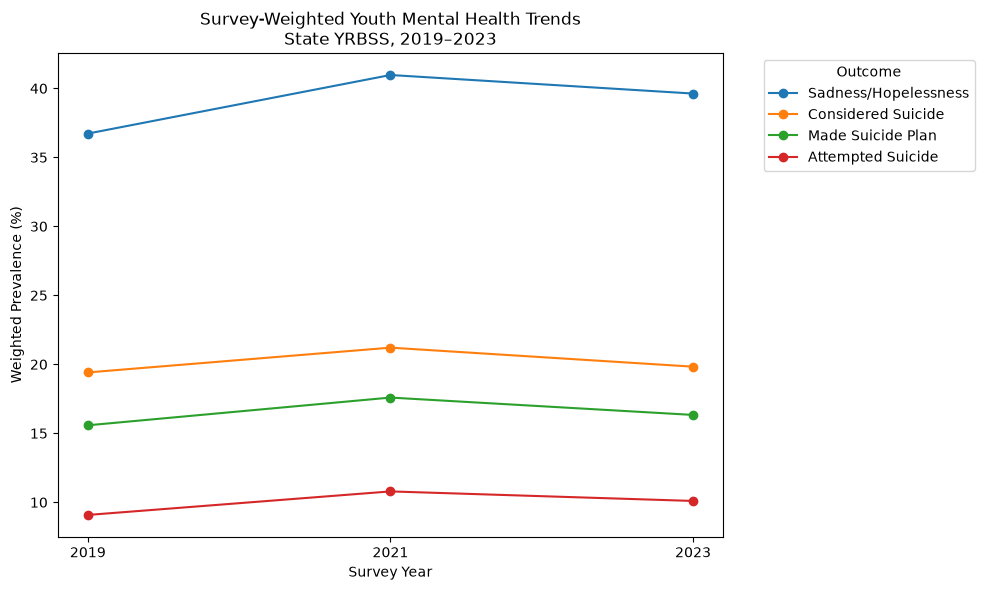

In [7]:
plt.figure(figsize=(10, 6))

for outcome in state_trends["outcome"].unique():
    temp = state_trends[
        state_trends["outcome"] == outcome
    ]

    plt.plot(
        temp["year"],
        temp["prevalence"],
        marker="o",
        label=outcome
    )

plt.title(
    "Survey-Weighted Youth Mental Health Trends\n"
    "State YRBSS, 2019–2023"
)

plt.xlabel("Survey Year")
plt.ylabel("Weighted Prevalence (%)")

plt.xticks([2019, 2021, 2023])

plt.legend(
    title="Outcome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Related Risk and Protective Trends

To complement the core mental-health outcomes, survey-weighted trends were examined for bullying, electronic bullying, sleep, and poor mental health. These measures provide context on potentially modifiable or intervention-relevant factors associated with youth mental health.

In [8]:
# Build weighted trends for related risk/protective measures

context_rows = []

# Binary outcomes that use Yes as the positive category
binary_context = {
    "bullied_at_school": "Bullied at School",
    "electronically_bullied": "Electronically Bullied",
}

for year in [2019, 2021, 2023]:
    year_df = state[state["year"] == year]

    for variable, label in binary_context.items():
        prevalence = weighted_prevalence(
            year_df,
            variable,
            positive_value="Yes"
        )

        context_rows.append({
            "year": year,
            "measure": label,
            "prevalence": prevalence
        })

# Poor mental health only has useful coverage in 2021 and 2023
# Treat Sometimes / Most of the time / Always as elevated poor mental health
for year in [2021, 2023]:
    year_df = state[state["year"] == year]

    temp = year_df[
        ["poor_mental_health", "weight"]
    ].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    elevated_categories = [
        "Sometimes",
        "Most of the time",
        "Always"
    ]

    elevated = temp["poor_mental_health"].isin(
        elevated_categories
    )

    prevalence = (
        temp.loc[elevated, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

    context_rows.append({
        "year": year,
        "measure": "Poor Mental Health",
        "prevalence": prevalence
    })


context_trends = pd.DataFrame(context_rows)

print(
    context_trends
    .pivot(
        index="year",
        columns="measure",
        values="prevalence"
    )
    .round(1)
)

measure  Bullied at School  Electronically Bullied  Poor Mental Health
year                                                                  
2019                  18.9                    14.5                 NaN
2021                  15.4                    15.0                58.5
2023                  19.2                    16.3                57.4


In [9]:
# Calculate weighted prevalence of insufficient sleep (< 8 hours)

insufficient_sleep_categories = [
    "4 or fewer hours",
    "5 hours",
    "6 hours",
    "7 hours"
]

sleep_rows = []

for year in [2019, 2021, 2023]:

    temp = state[
        state["year"] == year
    ][["sleep", "weight"]].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    insufficient = temp["sleep"].isin(
        insufficient_sleep_categories
    )

    prevalence = (
        temp.loc[insufficient, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

    sleep_rows.append({
        "year": year,
        "measure": "Less Than 8 Hours Sleep",
        "prevalence": prevalence
    })

sleep_trends = pd.DataFrame(sleep_rows)

print(sleep_trends.round(1))

   year                  measure  prevalence
0  2019  Less Than 8 Hours Sleep        78.1
1  2021  Less Than 8 Hours Sleep        77.8
2  2023  Less Than 8 Hours Sleep        79.0


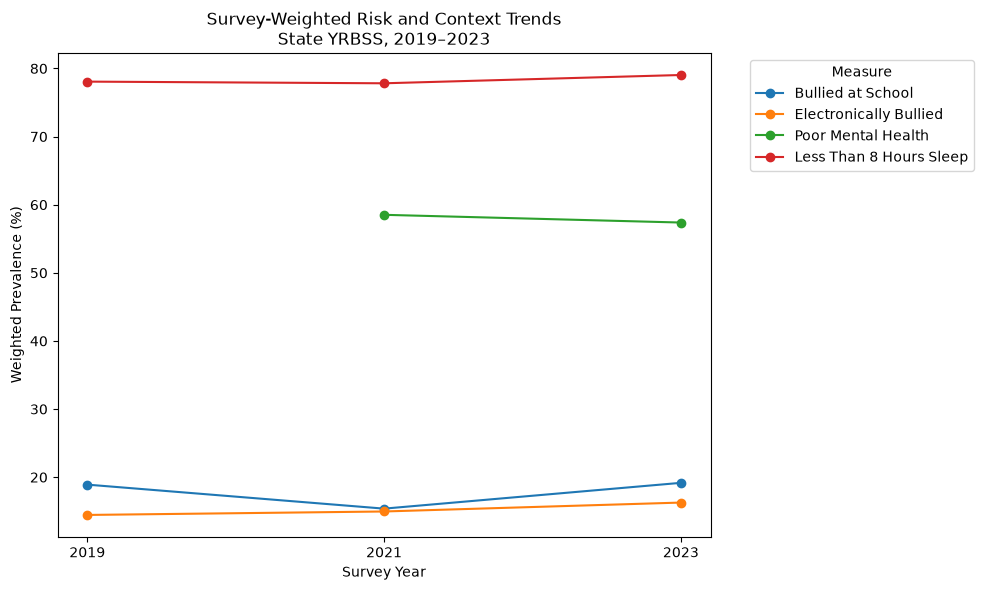

In [10]:
context_plot = pd.concat(
    [
        context_trends,
        sleep_trends
    ],
    ignore_index=True
)

plt.figure(figsize=(10, 6))

for measure in context_plot["measure"].unique():

    temp = context_plot[
        context_plot["measure"] == measure
    ]

    plt.plot(
        temp["year"],
        temp["prevalence"],
        marker="o",
        label=measure
    )

plt.title(
    "Survey-Weighted Risk and Context Trends\n"
    "State YRBSS, 2019–2023"
)

plt.xlabel("Survey Year")
plt.ylabel("Weighted Prevalence (%)")

plt.xticks([2019, 2021, 2023])

plt.legend(
    title="Measure",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation

The related risk and context measures show different patterns from the core mental-health outcomes.

Insufficient sleep was by far the most common condition across all three survey cycles. Nearly four in five students reported fewer than eight hours of sleep, and prevalence remained consistently high from 2019 through 2023.

School bullying declined between 2019 and 2021 before returning to approximately its pre-2021 level in 2023. Electronic bullying changed relatively little between 2019 and 2021 but increased in 2023.

Poor mental health, which is only available with sufficient coverage for 2021 and 2023, declined slightly between the two survey cycles but remained common among respondents with valid data.

Together, these trends suggest that the partial improvement seen in several mental-health outcomes in 2023 did not correspond to improvement across all potentially modifiable conditions. In particular, insufficient sleep remained highly prevalent, while bullying measures increased from their 2021 levels.

## State-Level Geographic Variation

The next analysis examines how youth mental-health burden varies across participating states. Survey-weighted prevalence estimates are calculated separately for each state so that high-burden jurisdictions can be identified.

In [11]:
# Calculate 2023 survey-weighted prevalence for each participating state

state_2023 = state[state["year"] == 2023].copy()

state_outcomes = {
    "persistent_sadness_hopelessness": "Sadness/Hopelessness",
    "considered_suicide": "Considered Suicide",
    "made_suicide_plan": "Made Suicide Plan",
    "attempted_suicide": "Attempted Suicide",
}

state_results = []

for state_name, group in state_2023.groupby("sitename"):

    row = {
        "state": state_name,
        "n": len(group)
    }

    for variable, label in state_outcomes.items():

        if variable == "attempted_suicide":
            temp = group[[variable, "weight"]].dropna().copy()

            temp["weight"] = pd.to_numeric(
                temp["weight"],
                errors="coerce"
            )

            temp = temp.dropna(subset=["weight"])

            if len(temp) > 0:
                positive = temp[variable] != "0 times"

                prevalence = (
                    temp.loc[positive, "weight"].sum()
                    / temp["weight"].sum()
                    * 100
                )
            else:
                prevalence = np.nan

        else:
            prevalence = weighted_prevalence(
                group,
                variable,
                positive_value="Yes"
            )

        row[label] = prevalence

    state_results.append(row)

state_2023_prevalence = pd.DataFrame(state_results)

state_2023_prevalence = (
    state_2023_prevalence
    .sort_values(
        "Sadness/Hopelessness",
        ascending=False
    )
)

print(
    state_2023_prevalence
    .round(1)
    .to_string(index=False)
)

                         state     n  Sadness/Hopelessness  Considered Suicide  Made Suicide Plan  Attempted Suicide
                  Indiana (IN)  1043                  47.0                25.2               23.6               15.7
                 Arkansas (AR)   706                  45.1                24.4               21.6               14.6
                 Oklahoma (OK)  1748                  44.9                23.3               18.4               12.1
                 Missouri (MO)   662                  44.3                25.6                NaN                NaN
                   Nevada (NV)  1471                  44.1                20.9               19.4               10.3
                  Montana (MT)  3610                  43.3                26.1               21.4               11.3
                   Alaska (AK)  1170                  43.2                22.6               20.5               19.0
                Tennessee (TN)  1573                  42.7      

C:\Users\akila\AppData\Local\Temp\ipykernel_84952\1561279083.py:19: RuntimeWarning: invalid value encountered in scalar divide
  temp.loc[positive, "weight"].sum()
C:\Users\akila\AppData\Local\Temp\ipykernel_84952\1561279083.py:19: RuntimeWarning: invalid value encountered in scalar divide
  temp.loc[positive, "weight"].sum()
C:\Users\akila\AppData\Local\Temp\ipykernel_84952\1561279083.py:19: RuntimeWarning: invalid value encountered in scalar divide
  temp.loc[positive, "weight"].sum()


In [12]:
def weighted_prevalence(df, outcome, positive_value="Yes"):
    """
    Calculate survey-weighted prevalence for a categorical outcome.
    Returns NaN when no valid weighted responses are available.
    """

    temp = df[[outcome, "weight"]].dropna().copy()

    temp["weight"] = pd.to_numeric(
        temp["weight"],
        errors="coerce"
    )

    temp = temp.dropna(subset=["weight"])

    if temp.empty or temp["weight"].sum() == 0:
        return np.nan

    positive = temp[outcome] == positive_value

    return (
        temp.loc[positive, "weight"].sum()
        / temp["weight"].sum()
        * 100
    )

### 2023 State Mental Health Burden

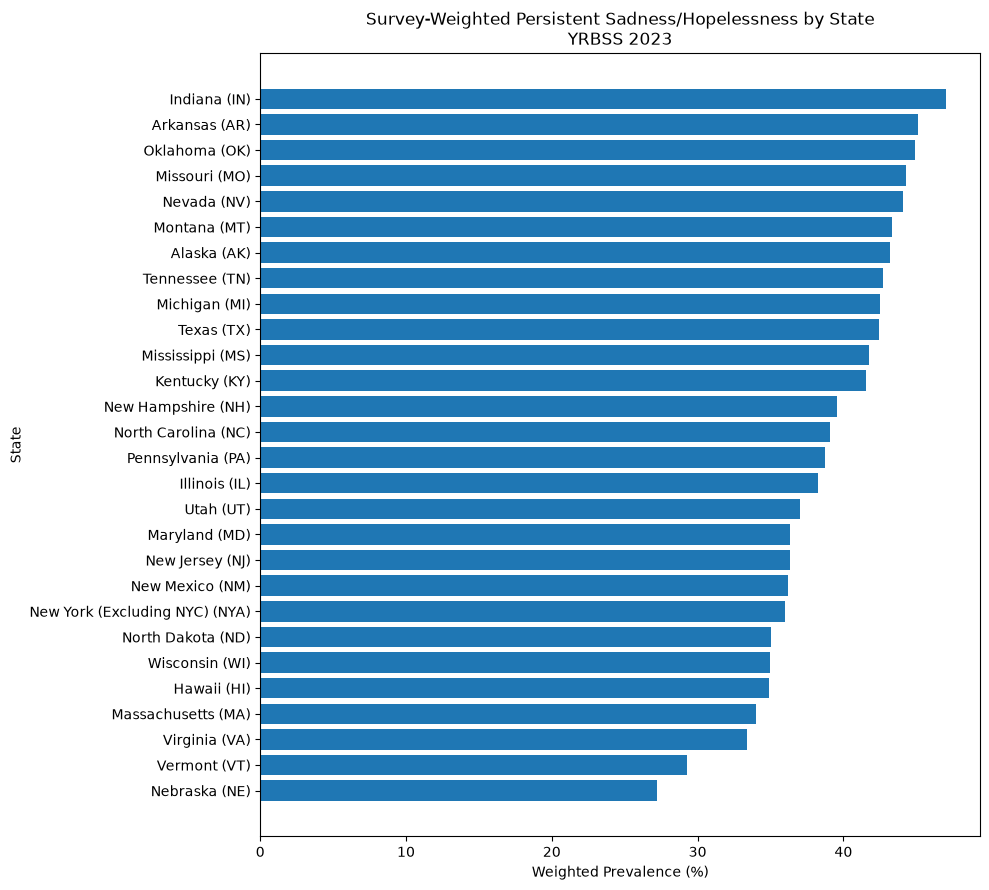

In [13]:
plot_states = (
    state_2023_prevalence
    .dropna(subset=["Sadness/Hopelessness"])
    .sort_values("Sadness/Hopelessness")
)

plt.figure(figsize=(10, 9))

plt.barh(
    plot_states["state"],
    plot_states["Sadness/Hopelessness"]
)

plt.title(
    "Survey-Weighted Persistent Sadness/Hopelessness by State\n"
    "YRBSS 2023"
)

plt.xlabel("Weighted Prevalence (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

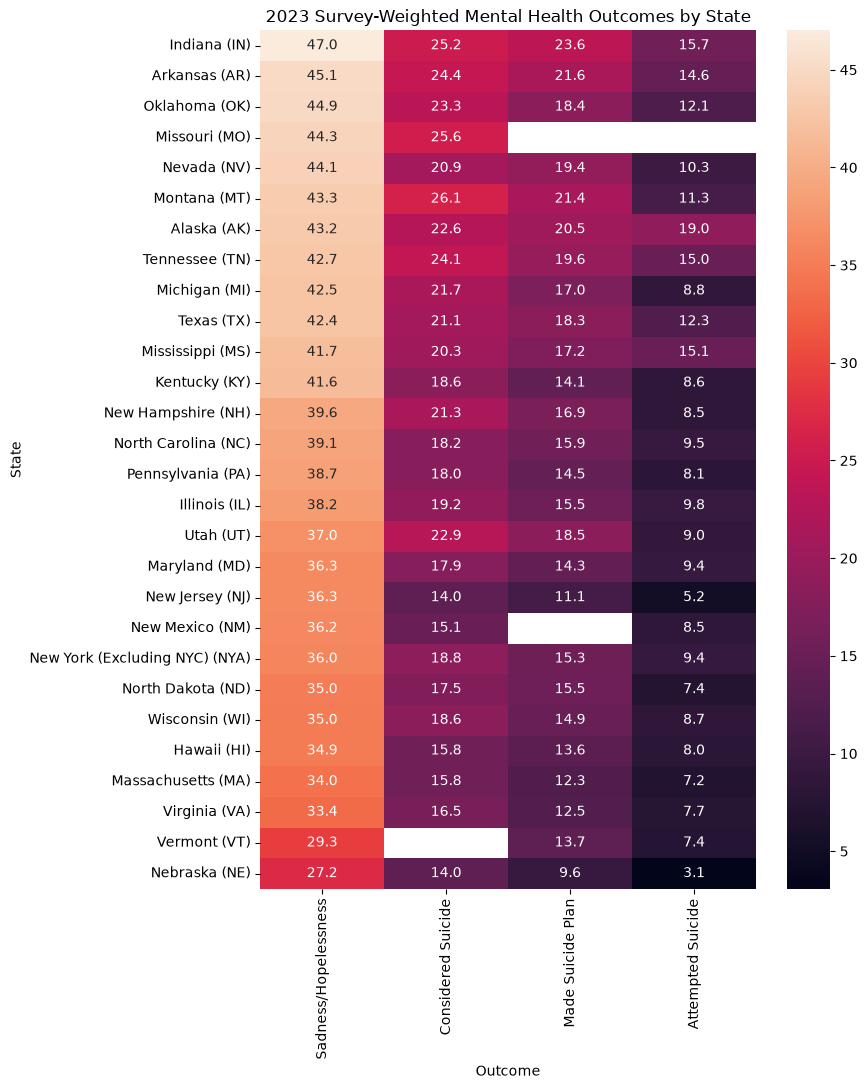

In [14]:
heatmap_data = (
    state_2023_prevalence
    .set_index("state")[
        [
            "Sadness/Hopelessness",
            "Considered Suicide",
            "Made Suicide Plan",
            "Attempted Suicide"
        ]
    ]
)

plt.figure(figsize=(9, 11))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title(
    "2023 Survey-Weighted Mental Health Outcomes by State"
)

plt.xlabel("Outcome")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Interpretation

Mental-health burden varied substantially across participating states in 2023.

Indiana had the highest survey-weighted prevalence of persistent sadness or hopelessness at 47.0%, followed by Arkansas at 45.1% and Oklahoma at 44.9%. Several of the states with high sadness/hopelessness also ranked highly across suicide-related outcomes, suggesting that elevated burden was not limited to a single measure.

However, the pattern was not identical across outcomes. Montana had the highest prevalence of considering suicide among the participating states shown at 26.1%, while Alaska had the highest prevalence of suicide attempts at 19.0%.

The heatmap highlights clusters of states with elevated burden across multiple mental-health outcomes while also showing that individual jurisdictions can have distinct outcome profiles. Missing cells reflect outcomes without sufficient available survey data for that state and should not be interpreted as zero prevalence.

## District-Level Geographic Variation

District-level YRBSS data provide the most local geographic view available in the combined survey files. Survey-weighted prevalence estimates are calculated separately for each participating district to identify local jurisdictions with elevated youth mental-health burden.

Because district participation varies across survey years, 2023 is used as the primary local snapshot.

In [15]:
# Calculate 2023 survey-weighted prevalence for each participating district

district_2023 = district[district["year"] == 2023].copy()

district_outcomes = {
    "persistent_sadness_hopelessness": "Sadness/Hopelessness",
    "considered_suicide": "Considered Suicide",
    "made_suicide_plan": "Made Suicide Plan",
    "attempted_suicide": "Attempted Suicide",
}

district_results = []

for district_name, group in district_2023.groupby("sitename"):

    row = {
        "district": district_name,
        "n": len(group)
    }

    for variable, label in district_outcomes.items():

        if variable == "attempted_suicide":
            temp = group[[variable, "weight"]].dropna().copy()

            temp["weight"] = pd.to_numeric(
                temp["weight"],
                errors="coerce"
            )

            temp = temp.dropna(subset=["weight"])

            if temp.empty or temp["weight"].sum() == 0:
                prevalence = np.nan
            else:
                positive = temp[variable] != "0 times"

                prevalence = (
                    temp.loc[positive, "weight"].sum()
                    / temp["weight"].sum()
                    * 100
                )

        else:
            prevalence = weighted_prevalence(
                group,
                variable,
                positive_value="Yes"
            )

        row[label] = prevalence

    district_results.append(row)

district_2023_prevalence = pd.DataFrame(
    district_results
)

district_2023_prevalence = (
    district_2023_prevalence
    .sort_values(
        "Sadness/Hopelessness",
        ascending=False
    )
)

print(
    district_2023_prevalence
    .round(1)
    .to_string(index=False)
)

                   district    n  Sadness/Hopelessness  Considered Suicide  Made Suicide Plan  Attempted Suicide
      Philadelphia, PA (PH) 1010                  46.0                21.4               19.1               13.2
       Los Angeles, CA (LO) 1323                  42.7                14.8               14.4               10.2
           Chicago, IL (CH) 1448                  40.6                15.7               12.1                7.3
         San Diego, CA (SA) 1488                  40.3                21.0                NaN               10.0
Spartanburg County, SC (SP) 1112                  37.5                 NaN               15.1                NaN
       Albuquerque, NM (AB) 3428                  36.8                14.5                NaN                8.0
    New York City, NY (NYC) 8338                  35.5                17.9                NaN               13.6
          Portland, OR (PO) 1343                  33.5                14.5               10.7   

### Interpretation

District-level results reveal substantial local variation within the 2023 YRBSS.

Philadelphia had the highest survey-weighted prevalence of persistent sadness or hopelessness among participating districts at 46.0%, followed by Los Angeles at 42.7%. Chicago and San Diego also exceeded 40%.

Philadelphia also showed elevated suicide-related burden, including 21.4% considering suicide, 19.1% making a suicide plan, and 13.2% attempting suicide.

However, district profiles were not uniform across outcomes. New York City had a lower sadness/hopelessness prevalence than several other districts at 35.5%, but its suicide-attempt prevalence was comparatively high at 13.6%.

These differences illustrate why district-level analysis adds value beyond state-level estimates. Local jurisdictions can show distinct combinations of mental-health burden even when they are located within the same broader state context.

Missing values indicate district-outcome combinations without sufficient available survey data and should not be interpreted as zero prevalence.

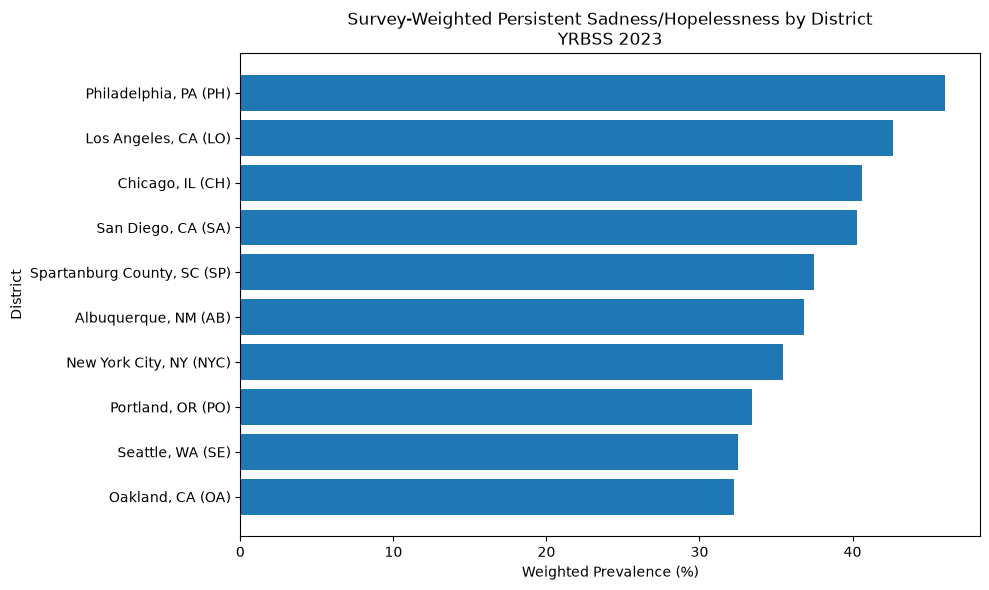

In [16]:
plot_districts = (
    district_2023_prevalence
    .dropna(subset=["Sadness/Hopelessness"])
    .sort_values("Sadness/Hopelessness")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_districts["district"],
    plot_districts["Sadness/Hopelessness"]
)

plt.title(
    "Survey-Weighted Persistent Sadness/Hopelessness by District\n"
    "YRBSS 2023"
)

plt.xlabel("Weighted Prevalence (%)")
plt.ylabel("District")

plt.tight_layout()
plt.show()

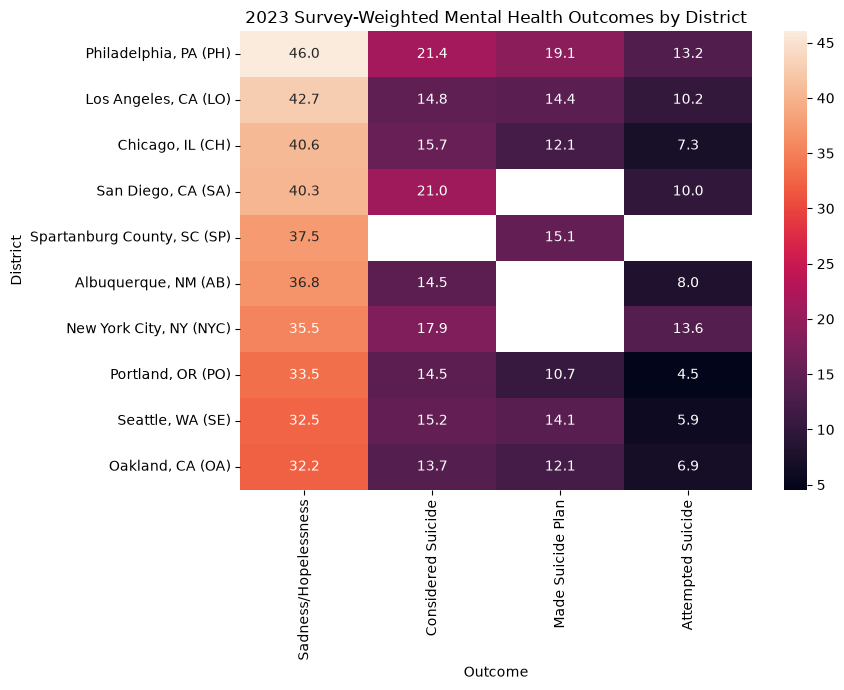

In [17]:
district_heatmap = (
    district_2023_prevalence
    .set_index("district")[
        [
            "Sadness/Hopelessness",
            "Considered Suicide",
            "Made Suicide Plan",
            "Attempted Suicide"
        ]
    ]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    district_heatmap,
    annot=True,
    fmt=".1f"
)

plt.title(
    "2023 Survey-Weighted Mental Health Outcomes by District"
)

plt.xlabel("Outcome")
plt.ylabel("District")

plt.tight_layout()
plt.show()

### District Trends Across Survey Years

To examine local change over time, district-level trends are calculated only for jurisdictions represented in multiple survey cycles. This avoids comparing different sets of districts as though they were the same local populations.

In [18]:
# Identify districts represented in at least two survey years

district_year_counts = (
    district
    .groupby("sitename")["year"]
    .nunique()
    .sort_values(ascending=False)
)

repeated_districts = district_year_counts[
    district_year_counts >= 2
].index.tolist()

print("Districts represented in at least two survey years:")
print(len(repeated_districts))

for name in repeated_districts:
    years = sorted(
        district.loc[
            district["sitename"] == name,
            "year"
        ].unique()
    )
    
    print(f"{name}: {years}")

Districts represented in at least two survey years:
17
Albuquerque, NM (AB): [np.int64(2019), np.int64(2021), np.int64(2023)]
New York City, NY (NYC): [np.int64(2019), np.int64(2021), np.int64(2023)]
Seattle, WA (SE): [np.int64(2019), np.int64(2021), np.int64(2023)]
San Diego, CA (SA): [np.int64(2019), np.int64(2021), np.int64(2023)]
Portland, OR (PO): [np.int64(2019), np.int64(2021), np.int64(2023)]
Philadelphia, PA (PH): [np.int64(2019), np.int64(2021), np.int64(2023)]
Oakland, CA (OA): [np.int64(2019), np.int64(2021), np.int64(2023)]
Los Angeles, CA (LO): [np.int64(2019), np.int64(2021), np.int64(2023)]
Chicago, IL (CH): [np.int64(2019), np.int64(2021), np.int64(2023)]
Spartanburg County, SC (SP): [np.int64(2019), np.int64(2021), np.int64(2023)]
Duval County, FL (DU): [np.int64(2019), np.int64(2021)]
Fort Worth, TX (FW): [np.int64(2019), np.int64(2021)]
Hillsborough County, FL (HL): [np.int64(2019), np.int64(2021)]
Broward County, FL (FT): [np.int64(2019), np.int64(2021)]
Orange Cou

In [19]:
# Calculate district-level sadness/hopelessness trends
# for jurisdictions represented in multiple survey years

district_trend_rows = []

for district_name in repeated_districts:

    district_subset = district[
        district["sitename"] == district_name
    ]

    for year in sorted(district_subset["year"].unique()):

        year_group = district_subset[
            district_subset["year"] == year
        ]

        prevalence = weighted_prevalence(
            year_group,
            "persistent_sadness_hopelessness",
            positive_value="Yes"
        )

        district_trend_rows.append({
            "district": district_name,
            "year": year,
            "prevalence": prevalence
        })

district_sadness_trends = pd.DataFrame(
    district_trend_rows
)

print(
    district_sadness_trends
    .pivot(
        index="district",
        columns="year",
        values="prevalence"
    )
    .round(1)
    .to_string()
)

year                          2019  2021  2023
district                                      
Albuquerque, NM (AB)          40.0  43.4  36.8
Broward County, FL (FT)       36.9  41.8   NaN
Chicago, IL (CH)              38.2  43.0  40.6
Duval County, FL (DU)         39.6  45.1   NaN
Fort Worth, TX (FW)           33.5  40.7   NaN
Hillsborough County, FL (HL)  37.6  48.9   NaN
Los Angeles, CA (LO)          34.0  40.9  42.7
New York City, NY (NYC)       35.9  38.2  35.5
Oakland, CA (OA)              31.6  44.4  32.2
Orange County, FL (OL)        37.1  41.7   NaN
Palm Beach County, FL (PB)    34.5  41.5   NaN
Pasco County, FL (PS)         42.2  45.2   NaN
Philadelphia, PA (PH)         40.3  44.6  46.0
Portland, OR (PO)             33.7  38.3  33.5
San Diego, CA (SA)            35.1  42.5  40.3
Seattle, WA (SE)              27.8  38.0  32.5
Spartanburg County, SC (SP)   35.4  38.8  37.5


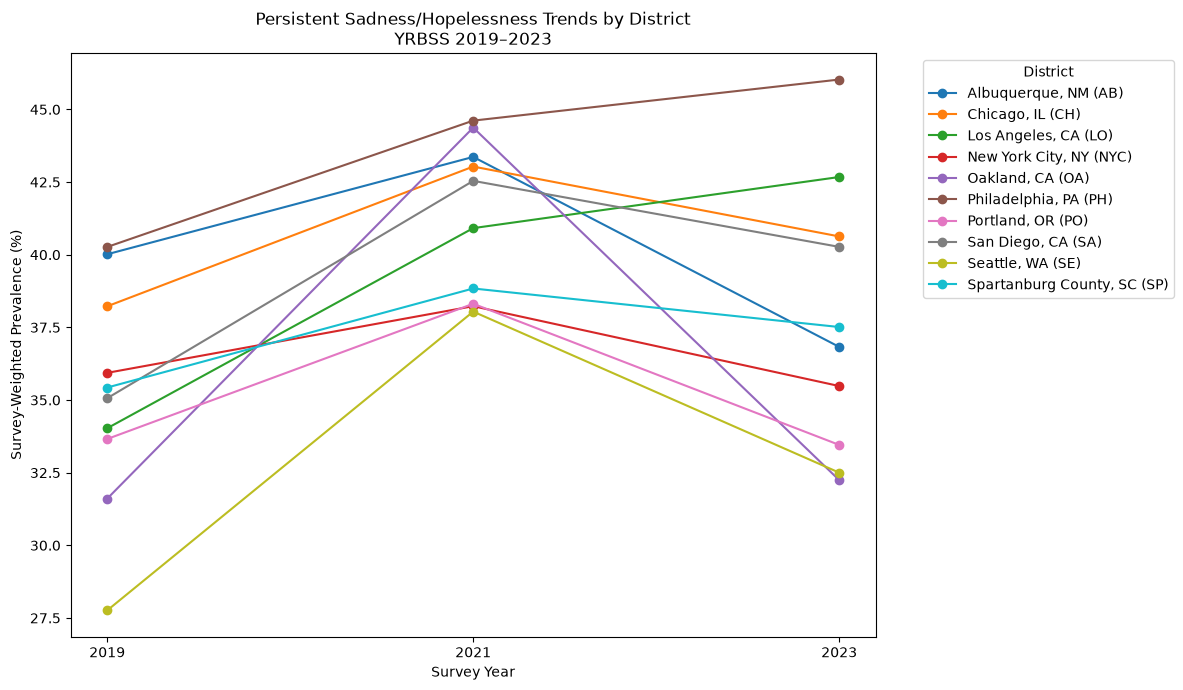

In [20]:
# Keep only districts represented in all three survey years

complete_districts = (
    district
    .groupby("sitename")["year"]
    .nunique()
)

complete_districts = complete_districts[
    complete_districts == 3
].index.tolist()

complete_trends = district_sadness_trends[
    district_sadness_trends["district"].isin(
        complete_districts
    )
].copy()

plt.figure(figsize=(12, 7))

for district_name in complete_districts:

    temp = complete_trends[
        complete_trends["district"] == district_name
    ]

    plt.plot(
        temp["year"],
        temp["prevalence"],
        marker="o",
        label=district_name
    )

plt.title(
    "Persistent Sadness/Hopelessness Trends by District\n"
    "YRBSS 2019–2023"
)

plt.xlabel("Survey Year")
plt.ylabel("Survey-Weighted Prevalence (%)")

plt.xticks([2019, 2021, 2023])

plt.legend(
    title="District",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation

Among the ten districts represented in all three survey cycles, local trends varied considerably.

Philadelphia and Los Angeles showed sustained increases in persistent sadness or hopelessness from 2019 through 2023. Philadelphia increased from 40.3% in 2019 to 46.0% in 2023, while Los Angeles increased from 34.0% to 42.7%.

Several districts followed the broader state-level pattern of worsening in 2021 followed by partial improvement in 2023. Chicago, San Diego, Seattle, and Spartanburg County remained above their 2019 levels in 2023, although below their 2021 peaks.

Other districts returned close to or below their 2019 levels. Oakland declined from a 2021 peak of 44.4% to 32.2% in 2023, while New York City and Portland returned approximately to their 2019 prevalence levels. Albuquerque declined below its 2019 estimate by 2023.

These differences suggest that the post-2021 trajectory was not geographically uniform. Some local jurisdictions experienced substantial recovery while others showed persistent or increasing mental-health burden.

## Statistical Analysis

To test whether geographic differences in youth mental-health burden are statistically meaningful, categorical association tests are applied to 2023 state and district data.

Chi-square tests are used because the primary outcomes are categorical. Cramér’s V is reported as an effect-size measure so that the strength of geographic association can be interpreted in addition to statistical significance.

In [21]:
from scipy.stats import chi2_contingency

In [22]:
def cramers_v(contingency_table):
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()

    if n == 0:
        return np.nan, p

    r, k = contingency_table.shape

    phi2 = chi2 / n

    correction = ((k - 1) * (r - 1)) / (n - 1)

    phi2corr = max(
        0,
        phi2 - correction
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(
        kcorr - 1,
        rcorr - 1
    )

    if denominator <= 0:
        return np.nan, p

    v = np.sqrt(
        phi2corr / denominator
    )

    return v, p

In [23]:
state_test = state[
    (state["year"] == 2023)
    & state["persistent_sadness_hopelessness"].notna()
].copy()

state_table = pd.crosstab(
    state_test["sitename"],
    state_test["persistent_sadness_hopelessness"]
)

state_v, state_p = cramers_v(
    state_table
)

print("2023 State vs Sadness/Hopelessness")
print(f"Cramér's V: {state_v:.3f}")
print(f"p-value: {state_p:.6g}")

2023 State vs Sadness/Hopelessness
Cramér's V: 0.086
p-value: 9.38098e-162


In [24]:
district_test = district[
    (district["year"] == 2023)
    & district["persistent_sadness_hopelessness"].notna()
].copy()

district_table = pd.crosstab(
    district_test["sitename"],
    district_test["persistent_sadness_hopelessness"]
)

district_v, district_p = cramers_v(
    district_table
)

print("2023 District vs Sadness/Hopelessness")
print(f"Cramér's V: {district_v:.3f}")
print(f"p-value: {district_p:.6g}")

2023 District vs Sadness/Hopelessness
Cramér's V: 0.066
p-value: 4.56125e-18


### Geographic Association With Sadness/Hopelessness

Geographic location was significantly associated with persistent sadness or hopelessness in 2023 at both the state and district levels.

At the state level, the association was statistically significant with Cramér’s V = 0.086. At the district level, the association was also statistically significant with Cramér’s V = 0.066.

Although the very small p-values indicate that the observed geographic differences are unlikely to be due to chance alone, the Cramér’s V values indicate relatively small effect sizes.

This means geography helps distinguish differences in youth mental-health burden, but geographic location by itself explains only part of the variation. The stronger individual-level risk and protective factors identified in the national YRBSS analysis remain important for understanding why mental-health outcomes differ.

In [25]:
context_factors = [
    "bullied_at_school",
    "electronically_bullied",
    "sleep",
]

context_results = []

for variable in context_factors:

    temp = state[
        (state["year"] == 2023)
        & state[variable].notna()
        & state["persistent_sadness_hopelessness"].notna()
    ].copy()

    table = pd.crosstab(
        temp[variable],
        temp["persistent_sadness_hopelessness"]
    )

    v, p = cramers_v(table)

    context_results.append({
        "factor": variable,
        "cramers_v": v,
        "p_value": p
    })

context_associations = pd.DataFrame(
    context_results
).sort_values(
    "cramers_v",
    ascending=False
)

print(
    context_associations
    .round(4)
    .to_string(index=False)
)

                factor  cramers_v  p_value
electronically_bullied     0.2674      0.0
     bullied_at_school     0.2569      0.0
                 sleep     0.2225      0.0


### Modifiable and Contextual Associations With Sadness/Hopelessness

Among the 2023 state YRBSS respondents, electronic bullying showed the strongest association with persistent sadness or hopelessness among the selected contextual factors (Cramér’s V = 0.267), followed closely by bullying at school (V = 0.257).

Sleep also showed a meaningful association with sadness or hopelessness (V = 0.223).

All three associations were statistically significant.

These effect sizes were notably larger than the association between geographic location itself and sadness or hopelessness. State geography had a Cramér’s V of 0.086 and district geography had a Cramér’s V of 0.066.

This suggests that geographic differences help identify where mental-health burden is concentrated, while individual experiences such as bullying and sleep may be more informative for understanding which potentially modifiable conditions are associated with that burden.

In [26]:
comparison_effects = pd.DataFrame({
    "factor": [
        "Electronic bullying",
        "Bullying at school",
        "Sleep",
        "State geography",
        "District geography"
    ],
    "cramers_v": [
        0.2674,
        0.2569,
        0.2225,
        state_v,
        district_v
    ]
}).sort_values(
    "cramers_v",
    ascending=False
)

print(
    comparison_effects
    .round(3)
    .to_string(index=False)
)

             factor  cramers_v
Electronic bullying      0.267
 Bullying at school      0.257
              Sleep      0.222
    State geography      0.086
 District geography      0.066


## Geographic Key Findings

The geographic YRBSS analysis showed that youth mental-health burden varies meaningfully across both states and local districts, but geography alone had a relatively small association with persistent sadness or hopelessness.

Across participating state samples, persistent sadness or hopelessness increased from 36.7% in 2019 to 41.0% in 2021 before declining slightly to 39.6% in 2023. Suicide consideration, planning, and attempts followed a similar pattern, with 2021 representing the highest prevalence across all four core outcomes.

State-level burden varied considerably in 2023. Indiana had the highest prevalence of persistent sadness or hopelessness at 47.0%, while Montana had the highest prevalence of considering suicide at 26.1%. Alaska had the highest prevalence of suicide attempts at 19.0%.

District-level analysis revealed additional local variation. Philadelphia had the highest prevalence of persistent sadness or hopelessness among participating 2023 districts at 46.0%, followed by Los Angeles at 42.7%. Philadelphia also showed elevated suicide-related burden.

Longitudinal district patterns were not uniform. Philadelphia and Los Angeles showed sustained increases in sadness or hopelessness from 2019 through 2023, while several other districts experienced a 2021 peak followed by partial or substantial improvement in 2023.

Geographic location was statistically associated with sadness or hopelessness, but effect sizes were small:
- State geography: Cramér’s V = 0.086
- District geography: Cramér’s V = 0.066

By comparison, potentially modifiable or intervention-relevant factors showed substantially stronger associations:
- Electronic bullying: Cramér’s V = 0.267
- Bullying at school: Cramér’s V = 0.257
- Sleep: Cramér’s V = 0.222

Overall, the geographic analysis suggests that state and district data are valuable for identifying where youth mental-health burden is concentrated and how local trends differ over time. However, individual experiences such as bullying and sleep appear more strongly associated with mental-health outcomes than geography itself.

These findings complement the national YRBSS analysis by distinguishing between **where burden is concentrated** and **which modifiable conditions are most strongly associated with that burden**.

### Analysis Note

State and district YRBSS samples were analyzed separately and survey weights were used for prevalence estimates. Missing jurisdiction-question combinations were preserved as missing rather than interpreted as zero. Associations are cross-sectional and should not be interpreted as causal.

In [28]:
# ============================================================
# FINAL_NOTEBOOK_TRANSFER_HELPER
# Compile all completed analysis notebooks into one final file
# ============================================================

from pathlib import Path
import nbformat

# Current notebook is inside:
# notebooks/Data_Analysis_Notebooks/

analysis_dir = Path(".")
final_dir = Path("../Final_Data_Analysis")

final_dir.mkdir(
    parents=True,
    exist_ok=True
)

final_notebook_path = (
    final_dir / "07_full_project_analysis.ipynb"
)

# Analysis notebooks in the order they should appear
source_files = [
    analysis_dir / "01_nsch_data_analysis.ipynb",
    analysis_dir / "02_acs_data_analysis.ipynb",
    analysis_dir / "03_nces_fiscal_data_analysis.ipynb",
    analysis_dir / "04_nces_nonfiscal_data_analysis.ipynb",
    analysis_dir / "05_hpsa_data_analysis.ipynb",
    analysis_dir / "06_yrbss_data_analysis.ipynb",
    analysis_dir / "07_yrbss_geographic_data_analysis.ipynb",
]

# Create a fresh final notebook
final_nb = nbformat.v4.new_notebook()

compiled_cells = []

for source_path in source_files:

    if not source_path.exists():
        print(f"SKIPPED - not found: {source_path.name}")
        continue

    print(f"Adding: {source_path.name}")

    with open(
        source_path,
        "r",
        encoding="utf-8"
    ) as f:
        source_nb = nbformat.read(
            f,
            as_version=4
        )

    for cell in source_nb.cells:

        # Do not copy transfer-helper cells into final notebook
        if (
            cell.cell_type == "code"
            and "FINAL_NOTEBOOK_TRANSFER_HELPER"
            in cell.source
        ):
            continue

        compiled_cells.append(cell)

# Add all collected cells
final_nb.cells = compiled_cells

# Write final notebook
with open(
    final_notebook_path,
    "w",
    encoding="utf-8"
) as f:
    nbformat.write(
        final_nb,
        f
    )

print("\n====================================")
print("FINAL NOTEBOOK REBUILT")
print("====================================")
print("Output:", final_notebook_path)
print("Total cells:", len(final_nb.cells))

Adding: 01_nsch_data_analysis.ipynb
Adding: 02_acs_data_analysis.ipynb
Adding: 03_nces_fiscal_data_analysis.ipynb
Adding: 04_nces_nonfiscal_data_analysis.ipynb
Adding: 05_hpsa_data_analysis.ipynb
Adding: 06_yrbss_data_analysis.ipynb
Adding: 07_yrbss_geographic_data_analysis.ipynb

FINAL NOTEBOOK REBUILT
Output: ..\Final_Data_Analysis\07_full_project_analysis.ipynb
Total cells: 304
